# Phase 1 — Warm-up: Adiabatic preparation of a 2D antiferromagnet

**CERN QTI Hackathon — Quantum twin of TmMgGaO₄**

This notebook reproduces the landmark result of
[Scholl et al., *Programmable quantum simulation of 2D antiferromagnets
with hundreds of Rydberg atoms*, Nature **595**, 233 (2021),
arXiv:2012.12268](https://arxiv.org/abs/2012.12268): a square array of
Rydberg atoms is swept quasi-adiabatically from a trivial paramagnet into
the antiferromagnetic (checkerboard) ordered ground state of the 2D
transverse-field Ising model.

This is the "clean, well-understood target" the challenge brief asks us
to use to shake out the whole toolchain (Pulser sequence building +
emulation + observable extraction) before tackling the real material in
Phase 2.

**What we build:**
1. A square Rydberg register.
2. A quasi-adiabatic pulse: Ω(t) ramps up then down, δ(t) sweeps from
   large negative (paramagnet) to positive (favours Rydberg excitation).
3. We tune the **blockade radius** R_b (via Ω_max) to sit strictly
   between the nearest-neighbour spacing `a` and the next-nearest-neighbour
   spacing `a√2`, so that neighbouring atoms are blocked from both being
   excited, but diagonal (next-nearest) neighbours are not — the
   condition for checkerboard order.
4. We measure the **staggered magnetisation** as our order parameter.


In [1]:
import sys, time
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt

import material_mapping as mm
from pulser_simulation import QutipBackendV2
from pulser.backend import EmulationConfig, Occupation

np.set_printoptions(precision=3, suppress=True)


## 1. Register and blockade-radius tuning

We use a small `n_side × n_side` square array so this runs comfortably on
a laptop CPU with an *exact* state-vector emulator (`QutipBackendV2`).
Scale `n_side` up (8, 10, ...) once you have GPU access to `emu_mps`
available — see the note at the end of this notebook.


In [2]:
n_side = 3          # -> N = 9 atoms; try 4-6 with emu_mps on a GPU
spacing = 5.0        # um
device = mm.build_device(rydberg_level=60, min_atom_distance=4.0)

register = mm.square_register(n_side, n_side, spacing=spacing)
print(f"N = {len(register.qubits)} atoms, spacing a = {spacing} um")

# Blockade radius strictly between a (NN) and a*sqrt(2) (next-NN):
Rb_ratio = 1.2
Rb = Rb_ratio * spacing
Omega_max = device.rabi_from_blockade(Rb)
print(f"Blockade radius Rb = {Rb:.2f} um  (a={spacing}, a*sqrt2={spacing*np.sqrt(2):.2f})")
print(f"=> Omega_max/2pi = {Omega_max/(2*np.pi):.3f} MHz")


N = 9 atoms, spacing a = 5.0 um
Blockade radius Rb = 6.00 um  (a=5.0, a*sqrt2=7.07)
=> Omega_max/2pi = 2.953 MHz


## 2. Quasi-adiabatic sequence

Following Ext. Dat. Fig. 4a of Leclerc et al. (the same protocol family
used for TmMgGaO₄ in Phase 2), we ramp Ω up, hold/sweep δ across
resonance, then ramp Ω back down before the (implicit) readout.


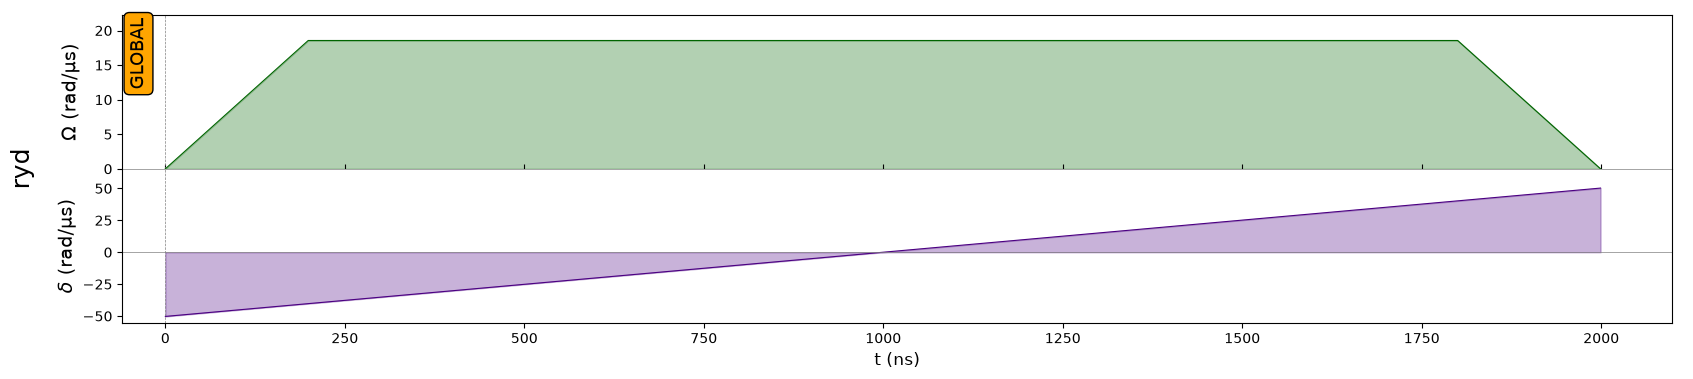

In [3]:
seq = mm.afm_prep_sequence(
    register, device,
    Omega_max=Omega_max,
    delta_start=-2 * np.pi * 8.0,   # rad/us: deep paramagnet
    delta_end=2 * np.pi * 8.0,      # rad/us: favours checkerboard order
    t_rise=200, t_sweep=1600, t_fall=200,   # ns
)
seq.draw()


## 3. Emulate and extract the staggered magnetisation

In [4]:
eval_times = list(np.linspace(0.05, 1.0, 25))
cfg = EmulationConfig(observables=[Occupation(evaluation_times=eval_times)])

t0 = time.time()
backend = QutipBackendV2(seq, config=cfg)
results = backend.run()
print(f"Emulation took {time.time()-t0:.1f} s")

staggered = np.array([[(-1) ** (i + j) for j in range(n_side)] for i in range(n_side)])

def staggered_mag(occ):
    sz = mm.sz_from_occupation(np.array(occ)).reshape(n_side, n_side)
    return np.mean(sz * staggered)

m_stag = [staggered_mag(o) for o in results.occupation]
times_ns = np.array(eval_times) * seq.get_duration()
print(f"Final staggered magnetisation |m| = {abs(m_stag[-1]):.3f}")


Emulation took 0.6 s
Final staggered magnetisation |m| = 0.970


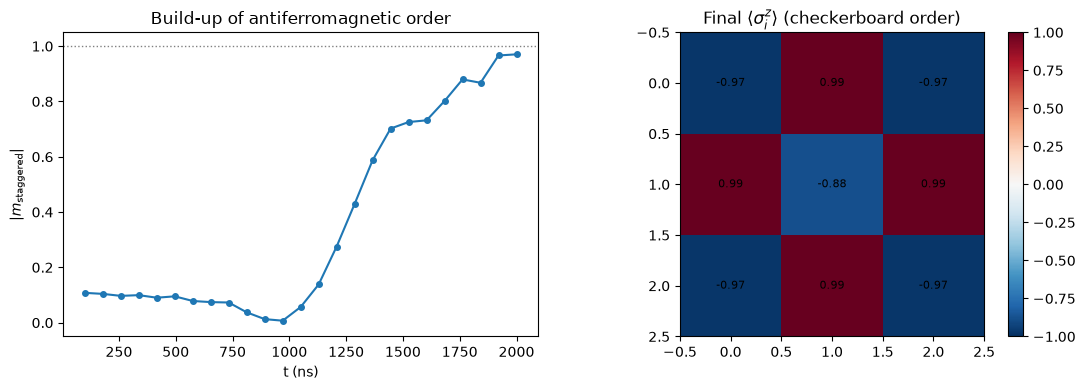

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(times_ns, np.abs(m_stag), "-o", ms=4)
axes[0].set_xlabel("t (ns)")
axes[0].set_ylabel(r"$|m_{\mathrm{staggered}}|$")
axes[0].set_title("Build-up of antiferromagnetic order")
axes[0].axhline(1.0, color="gray", ls=":", lw=1)
axes[0].set_ylim(-0.05, 1.05)

final_occ = np.array(results.occupation[-1])
sz_grid = mm.sz_from_occupation(final_occ).reshape(n_side, n_side)
im = axes[1].imshow(sz_grid, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(r"Final $\langle \sigma^z_i \rangle$ (checkerboard order)")
for i in range(n_side):
    for j in range(n_side):
        axes[1].text(j, i, f"{sz_grid[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig("phase1_afm_result.png", dpi=140)
plt.show()


## Notes on scaling up

* On this `3x3` system the checkerboard order forms cleanly (`|m|` close
  to 1) with a short (~2 μs) sweep. **This is finite-size-friendly and
  won't reproduce as cleanly on larger arrays with the same sweep
  duration** — the adiabatic gap shrinks as the system grows, so bigger
  lattices need proportionally longer sweeps (or optimal-control pulse
  shaping, see the Pulser "Optimal Control for AFM State Preparation"
  tutorial mentioned in the challenge brief).
* To go to `N = 8x8 = 64` or beyond, swap `QutipBackendV2` for
  `emu_mps.MPSBackend` (see Notebook 2 for the exact usage pattern) and
  run on a GPU.
* Deliverable for Phase 1 (per the challenge table): this notebook *is*
  that deliverable — detuning sweep + measured staggered magnetisation
  (we also have direct access to the AFM structure factor via
  `pulser.backend.CorrelationMatrix`, left as a one-line extension).
